# Predicción de dirección del S&P 500 con Machine Learning

## Descripción del proyecto

Este proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de predecir si el precio del S&P 500 subirá o bajará en la siguiente vela horaria, utilizando datos históricos con frecuencia H1.

## Tipo de problema

Clasificación binaria:

- 1: el precio sube en la siguiente vela.
- 0: el precio no sube o baja en la siguiente vela.

## Dataset

Fuente: Yahoo Finance.  
Activo: S&P 500.  
Frecuencia: H1.  
Cantidad aproximada de registros: 3500.  
Variables originales: Open, High, Low, Close, Volume.

## Estado actual - Entrega 2

En esta etapa se desarrolló el núcleo técnico del sistema:

- Carga del dataset.
- Limpieza y preprocesamiento.
- Creación de variables predictoras.
- Definición del target binario.
- División temporal entre entrenamiento y prueba.
- Entrenamiento de un modelo Random Forest.
- Predicción sobre conjunto de test.
- Evaluación mediante accuracy, precision, recall y F1-score.

## Modelo utilizado

Se utilizó Random Forest como modelo inicial debido a su buen desempeño en datos tabulares, su robustez frente al ruido y su capacidad para capturar relaciones no lineales.

## Métricas de evaluación

Las métricas utilizadas fueron:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

## Limitaciones

El modelo es una primera aproximación experimental.
No garantiza rentabilidad financiera ni debe utilizarse como recomendación de inversión.
El objetivo de esta etapa es demostrar que el pipeline técnico funciona correctamente.

## Próximos pasos

- Comparar Random Forest con XGBoost.
- Ajustar hiperparámetros.
- Probar nuevas features técnicas.
- Evaluar el modelo en distintos períodos.
- Desarrollar una interfaz simple en Streamlit.

# Modelado predictivo del S&P 500 con Machine Learning

En este notebook se desarrolla una primera versión funcional del núcleo técnico del sistema.
El objetivo es entrenar un modelo de Machine Learning supervisado para predecir si el precio de cierre del S&P 500 subirá o bajará en la siguiente vela horaria.

El problema se plantea como una tarea de clasificación binaria:

- 1: el precio sube en la siguiente hora.
- 0: el precio no sube o baja en la siguiente hora.

Esta versión no busca garantizar rentabilidad financiera, sino demostrar un pipeline técnico funcional de carga de datos, preprocesamiento, entrenamiento, predicción y evaluación.

## Importación de Librerias

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

## Descarga de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/cs de datos data set/SP500_2_anios_h1.csv', skiprows=[1, 2])

df.head()

,Price,Close,High,Low,Open,Volume
0,2024-04-11 13:30:00+00:00,5143.169922,5176.140137,5138.770020,5172.950195,0
1,2024-04-11 14:30:00+00:00,5152.750000,5158.680176,5141.990234,5143.149902,246598771
2,2024-04-11 15:30:00+00:00,5165.939941,5172.439941,5151.959961,5152.750000,201089760
3,2024-04-11 16:30:00+00:00,5192.520020,5195.729980,5164.979980,5165.990234,201419150
4,2024-04-11 17:30:00+00:00,5207.830078,5209.500000,5187.689941,5192.609863,220782000


## Exploración y Limpieza de Datos

In [ ]:
# Verificar nombres de columnas
print(df.columns)

# Si la columna de fecha viene como 'Price', la renombramos a 'Datetime'
if 'Price' in df.columns:
    df = df.rename(columns={'Price': 'Datetime'})

# Si la fecha ya quedó como índice, la recuperamos como columna
if 'Datetime' not in df.columns and df.index.name == 'Datetime':
    df = df.reset_index()

# Limpiar y preparar columna de fecha
df = df.dropna(subset=['Datetime'])
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Ordenar temporalmente y usar Datetime como índice
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

df.head()

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-04-11 13:30:00+00:00,5143.169922,5176.140137,5138.770020,5172.950195,0
2024-04-11 14:30:00+00:00,5152.750000,5158.680176,5141.990234,5143.149902,246598771
2024-04-11 15:30:00+00:00,5165.939941,5172.439941,5151.959961,5152.750000,201089760
2024-04-11 16:30:00+00:00,5192.520020,5195.729980,5164.979980,5165.990234,201419150
2024-04-11 17:30:00+00:00,5207.830078,5209.500000,5187.689941,5192.609863,220782000


In [ ]:
df.info()

print("\nValores nulos por columna:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3483 entries, 2024-04-11 13:30:00+00:00 to 2026-04-10 19:30:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3483 non-null   float64
 1   High    3483 non-null   float64
 2   Low     3483 non-null   float64
 3   Open    3483 non-null   float64
 4   Volume  3483 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 163.3 KB

Valores nulos por columna:


,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
# Eliminación de Nulos si los hay
df = df.dropna()

In [ ]:
# Columnas Numéricas (Asegurarse que sean del tipo correcto)
cols_numericas = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

## Features Engineering

No conviene usar solo Open, High, Low, Close, Volume. Es mejor crear variables derivadas.

Features recomendadas:
Estas features son defendibles porque salen de los precios históricos y ayudan a representar momentum, volatilidad y comportamiento de la vela.

In [ ]:
df['return_1h'] = df['Close'].pct_change()
df['return_3h'] = df['Close'].pct_change(3)
df['return_6h'] = df['Close'].pct_change(6)

df['range'] = df['High'] - df['Low']
df['body'] = abs(df['Close'] - df['Open'])

df['ema_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['ema_20'] = df['Close'].ewm(span=20, adjust=False).mean()

df['volatility_10'] = df['return_1h'].rolling(window=10).std()

df = df.dropna()

## Variable Objetivo

Esta parte es clave.

El target tiene que mirar el cierre futuro:
Si el cierre de la próxima vela es mayor al cierre actual → 1
Si no → 0
Esto convierte el problema en clasificación binaria.

In [ ]:
df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna()

## Seleccion de Features

In [ ]:
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'return_1h', 'return_3h', 'return_6h',
    'range', 'body',
    'ema_10', 'ema_20',
    'volatility_10'
]

X = df[features]
y = df['target']

## Split Temporal
Dividir train/test respetando el tiempo

Este punto es importante. En series temporales no conviene mezclar aleatoriamente los datos.
Esto significa:

Primer 80% del tiempo: entrenamiento.
Último 20% del tiempo: prueba.

Es más correcto para datos financieros porque simula mejor el uso real del modelo.

In [ ]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print(f"Train: {len(X_train):,} muestras  ({X_train.index[0]} → {X_train.index[-1]})")
print(f"Test : {len(X_test):,}  muestras  ({X_test.index[0]} → {X_test.index[-1]})")


Train: 2,778 muestras  (2024-04-12 16:30:00+00:00 → 2025-11-13 17:30:00+00:00)
Test : 695  muestras  (2025-11-13 18:30:00+00:00 → 2026-04-10 19:30:00+00:00)


## Random Forest

### Entrenamiento

Para esta entrega, usá Random Forest. Es más simple de defender que XGBoost y no requiere tanta configuración.
Se eligió Random Forest porque es un modelo adecuado para datos tabulares, permite capturar relaciones no lineales y es robusto frente al ruido. Además, funciona bien como primera aproximación sin requerir una arquitectura compleja.

In [ ]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight='balanced'
)

modelo.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

### Predicciones

In [ ]:
y_pred = modelo.predict(X_test)

y_pred[:10]

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0])

También podés obtener probabilidades:
Eso te sirve para decir que el modelo no solo predice 0 o 1, sino que también puede entregar una probabilidad estimada.

In [ ]:
y_proba = modelo.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.47494243, 0.48093063, 0.53960437, 0.4658686 , 0.51759322,
       0.46163826, 0.45985471, 0.46261506, 0.46603299, 0.49814681])

### Evaluacion del modelo

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.4935251798561151
Precision: 0.5174129353233831
Recall: 0.28969359331476324
F1-score: 0.37142857142857144


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.71      0.58       336
           1       0.52      0.29      0.37       359

    accuracy                           0.49       695
   macro avg       0.50      0.50      0.47       695
weighted avg       0.50      0.49      0.47       695



### Confusion Matrix

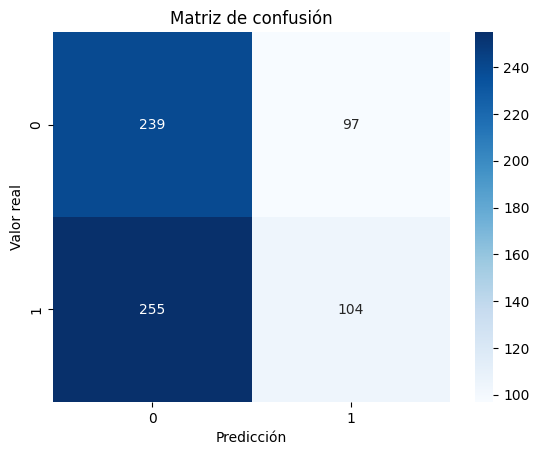

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión')
plt.show()

### Importancia de variables



In [ ]:
importancias = pd.DataFrame({
    'feature': features,
    'importance': modelo.feature_importances_
}).sort_values(by='importance', ascending=False)

importancias

,feature,importance
12,volatility_10,0.111746
7,return_6h,0.106934
9,body,0.101690
6,return_3h,0.084604
5,return_1h,0.081281
8,range,0.080529
4,Volume,0.075022
2,Low,0.066238
10,ema_10,0.064014
3,Close,0.060377


El modelo asignó mayor importancia a determinadas variables relacionadas con precio, retorno y volatilidad.

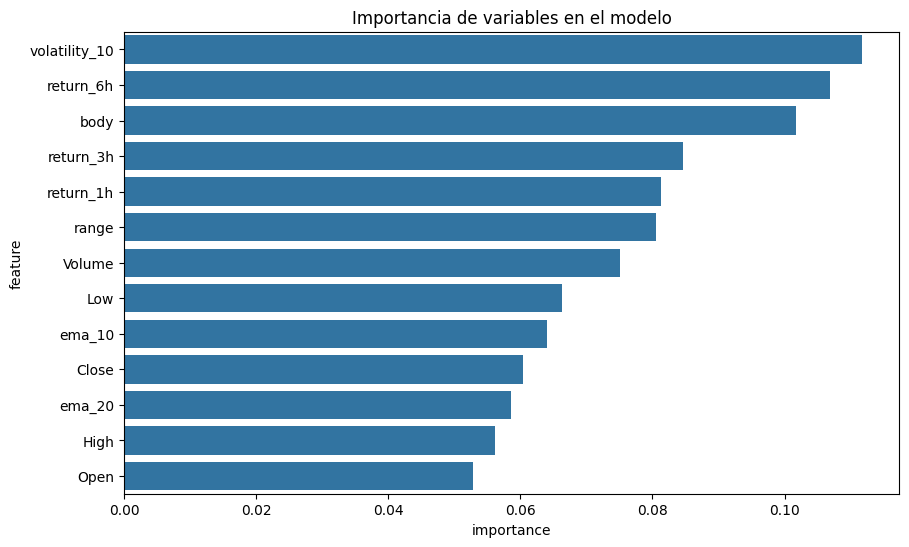

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='importance', y='feature')
plt.title('Importancia de variables en el modelo')
plt.show()

## Conclusión

En esta entrega se implementó una primera versión funcional del núcleo técnico del sistema.
Se cargó el dataset histórico del S&P 500 con frecuencia horaria, se realizó preprocesamiento, se generaron variables predictoras y se construyó un target binario para representar la dirección futura del precio.

Luego se entrenó un modelo Random Forest y se realizaron predicciones sobre un conjunto de test separado temporalmente.
La evaluación se realizó mediante métricas de clasificación como accuracy, precision, recall y F1-score.

Los resultados obtenidos deben interpretarse como una primera aproximación experimental.
El modelo no garantiza rentabilidad ni predicción perfecta del mercado, pero permite demostrar que el pipeline de Machine Learning está operativo y que el sistema puede ser mejorado en próximas etapas.

## Justificación de decisiones técnicas

Se eligió un enfoque de Machine Learning clásico porque el dataset disponible contiene datos tabulares históricos del S&P 500, compuestos por variables OHLCV y features derivadas.
El problema se formuló como clasificación binaria, ya que el objetivo es predecir si el precio de cierre subirá o no en la siguiente vela horaria.

Se seleccionó Random Forest como primer modelo porque es adecuado para datos tabulares, permite capturar relaciones no lineales y es relativamente robusto frente al ruido.
También permite analizar la importancia de las variables, lo cual facilita la interpretación inicial del sistema.

Como alternativa se consideró XGBoost, pero se dejó para una etapa posterior porque requiere mayor ajuste de hiperparámetros.
También se descartaron redes neuronales en esta instancia, ya que el objetivo de la entrega es demostrar un núcleo funcional simple, interpretable y coherente con el problema.

La evaluación se realizó mediante accuracy, precision, recall y F1-score, métricas adecuadas para problemas de clasificación.
No se utilizaron métricas como MAE o RMSE porque corresponden principalmente a problemas de regresión.